# Maat 2001

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import enlighten
import shapely

from scipy.interpolate import interp1d

from utils import Modulator_CPW


from imodulator.ChargeSimulator import ChargeSimulatorSolcore, ChargeSimulatorNN
from imodulator.OpticalSimulator import OpticalSimulatorFEMWELL, OpticalSimulatorMODE
from imodulator.ElectroOpticalSimulator import ElectroOpticalSimulator
from imodulator.RFSimulator import RFSimulatorFEMWELL as RFSimulator

import skrf as rf

import os
import json

%matplotlib widget

Failed to import lumapi: [Errno 2] No such file or directory: 'C:/Program Files/Lumerical/v232/api/python/lumapi.py'


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\solcore\registries.py:73: UserWarning: Optics solver 'RCWA' will not be available. An installation of S4 has not been found.
  warn(
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\nextnanopy\defaults.py:202: UserWarning: Unsupported products in config file: ['nextnano.NEGF++'] will be ignored. To not see this message, please remove unsupported products from the config file: C:\Users\20230622\.nextnanopy-configNote: nextnano.NEGF++ was renamed to nextnano.NEGF, nextnano.NEGF was renamed to nextnano.NEGF_classic. Please check the documentation for more details.
  warnings.warn(


Successfully imported nextnanopy
Successfully configured nextnano++ settings
  [OK] nextnano++ exe: C:/Program Files/nextnano/2026_07_03/nextnano++/bin/nextnano++_Intel_64bit.exe
  [OK] nextnano++ license: C:/Users/20230622/OneDrive - TU Eindhoven/PhD/License_nnp.lic
  [OK] nextnano++ database: C:/Program Files/nextnano/2026_07_03/nextnano++/database/database.nnp
  [OK] nextnano++ outputdirectory: D:/Repos/imodulator/tests\nn_output
nextnano configuration test passed: all paths are valid.


In this notebook we will replicate the absorption plots from [1], in particular Fig.3.2. To see details on the cross section and model build please look at the source code in the repo in the `utils.py`.

[1] D. H. P. Maat, InP-based integrated MZI switches for optical communication. 2001.


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: overflow encountered in exp
  result_magnitude = func(*stripped_args, **stripped_kwargs)


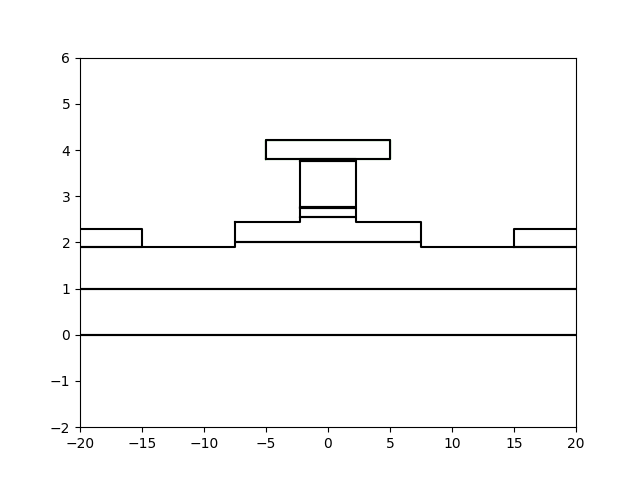

In [2]:
modulator = Modulator_CPW()
modulator.device.plot_polygons()
plt.xlim(-20,20)
plt.ylim(-2,6)
plt.show()

Charge transport will take place with:
L6
L5
etchstop
L4
L3
L2
L1
Input file created: output_nn\quicksave.in

Simulation did not converge! Check the log:
C:\Users\20230622\OneDrive - TU Eindhoven\PhD\Reports and papers\16. Imodulator paper\Generic_InP\maat\quicksave\quicksave.log


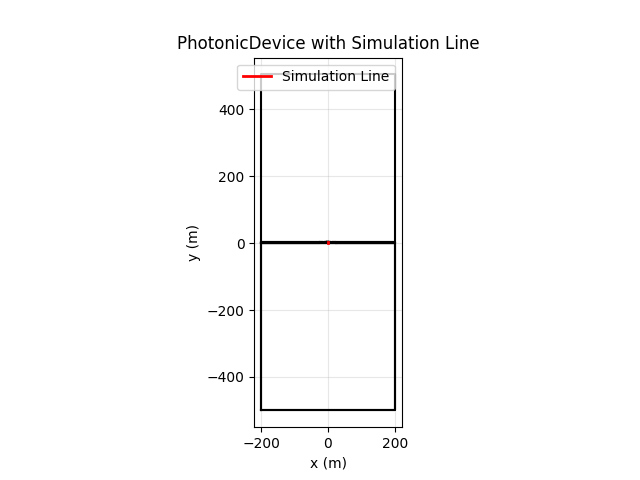

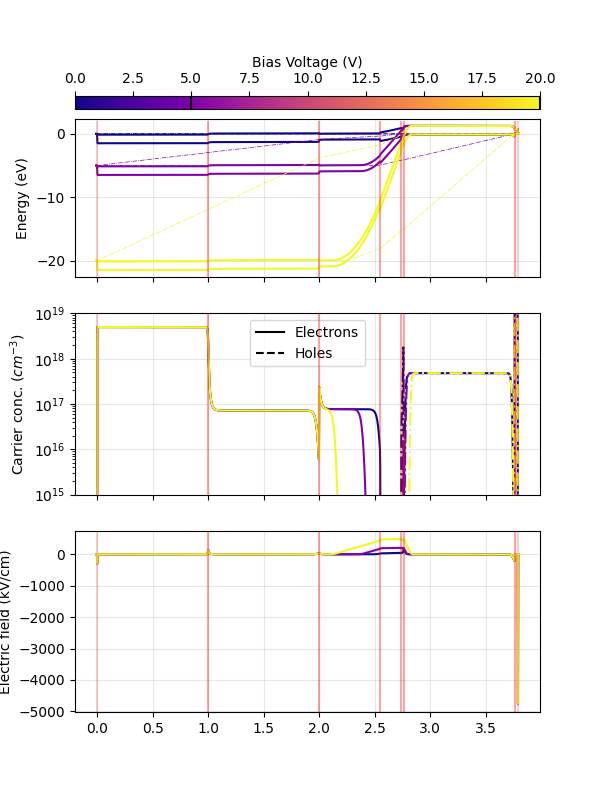

In [3]:
a=shapely.LineString([
    [0,0+0.001],
    [0,modulator.h_L1 + modulator.h_L2+modulator.h_L3+modulator.h_L4+modulator.h_L5+modulator.h_L6-0.001]])

charge=ChargeSimulatorNN(
    device=modulator.device,
    simulation_line=a,
    bias_start_stop_step=[0,20,21],
	output_directory=r"output_nn"
)

charge.plot_with_simulation_line()

charge.NNinputf.execute(
	show_log=False, 
	convergenceCheck=True, 
	convergence_check_mode="continue", 
	outputdirectory=r"C:\Users\20230622\OneDrive - TU Eindhoven\PhD\Reports and papers\16. Imodulator paper\Generic_InP\maat")

charge.load_output_data(folderpath=r"C:\Users\20230622\OneDrive - TU Eindhoven\PhD\Reports and papers\16. Imodulator paper\Generic_InP\maat\quicksave")

charge.plot_results(
    V_idx = [0, 5, 20],
    cmap = 'plasma',
	plot_limits=True,
)
charge.transfer_results_to_device(
	dx = 0.5,
	polygons_to_map = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'etchstop'])

In [4]:
modulator.device.charge['Efield'][-1](0,2.72)

Magnitude,[0.0 483.91179654097 0.0]
Units,kilovolt/centimeter


15996


(<Figure size 800x400 with 4 Axes>,
 [<Axes: title={'center': '$\\epsilon_{xx}$ real part'}, xlabel='x (um)', ylabel='y (um)'>,
  <Axes: title={'center': '$\\epsilon_{xx}$ imaginary part'}, xlabel='x (um)', ylabel='y (um)'>])

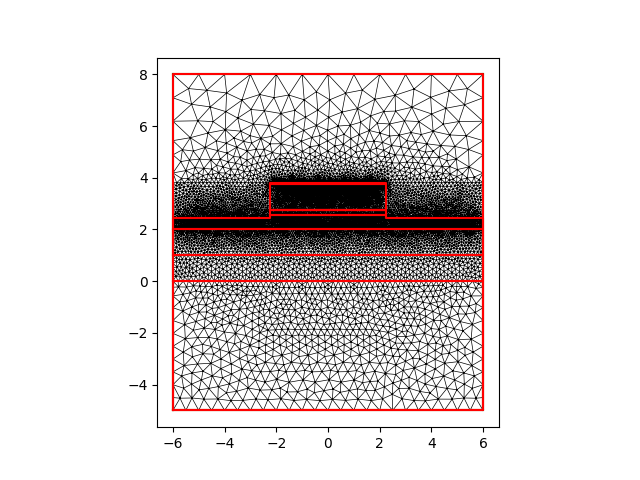

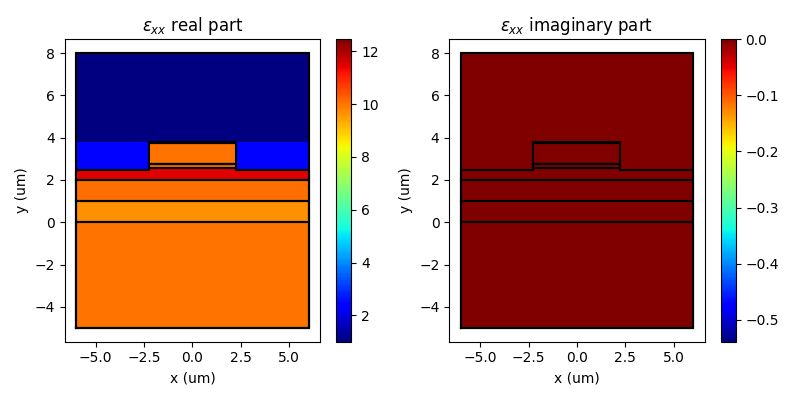

In [5]:
mode = OpticalSimulatorFEMWELL(
            device=modulator.device,
			simulation_window=shapely.box(-6, -5, 6,8),
            include_metals=True*0
        )
mode.make_mesh(gmsh_algorithm=1)
mode.plot_mesh()

print(mode.mesh.nelements)

mode.plot_epsilon_optical()

Effective index - mode 0: 3.2961
loss - mode 0: 1.73 dB/cm
power:  (1+0j)
TE fraction:  0.9994265416802499
TM fraction:  0.0005734583197500864
transversality: 0.9979858719772031
#------------------------------------------#
Effective index - mode 1: 3.2894
loss - mode 1: 2.03 dB/cm
power:  (1+0j)
TE fraction:  0.0017144457198131882
TM fraction:  0.9982855542801868
transversality: 0.9697883159810426
#------------------------------------------#
Effective index - mode 2: 3.2852
loss - mode 2: 1.66 dB/cm
power:  (0.9999999999999999+0j)
TE fraction:  0.9976317542396768
TM fraction:  0.00236824576032324
transversality: 0.9921032990603569
#------------------------------------------#
Effective index - mode 3: 3.2784
loss - mode 3: 1.97 dB/cm
power:  (0.9999999999999999+0j)
TE fraction:  0.002704543205077568
TM fraction:  0.9972954567949225
transversality: 0.9695183090394761
#------------------------------------------#
Effective index - mode 4: 3.2676
loss - mode 4: 1.54 dB/cm
power:  (0.9999999

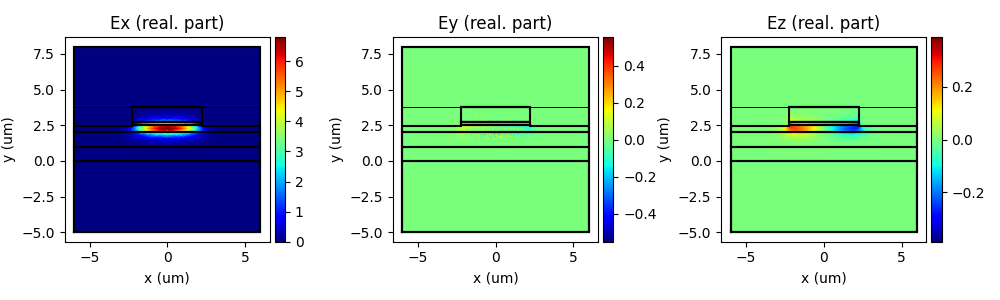

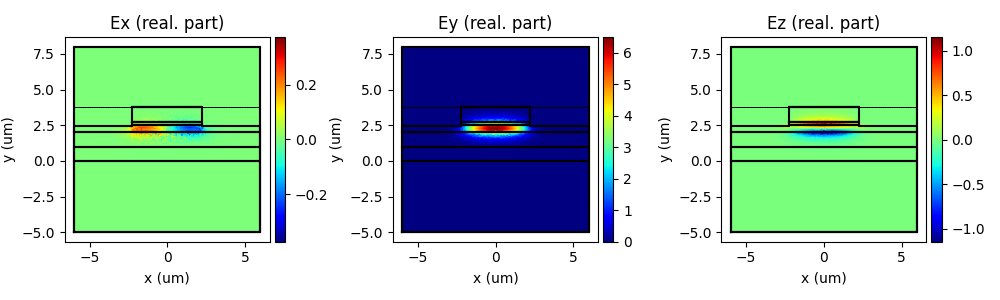

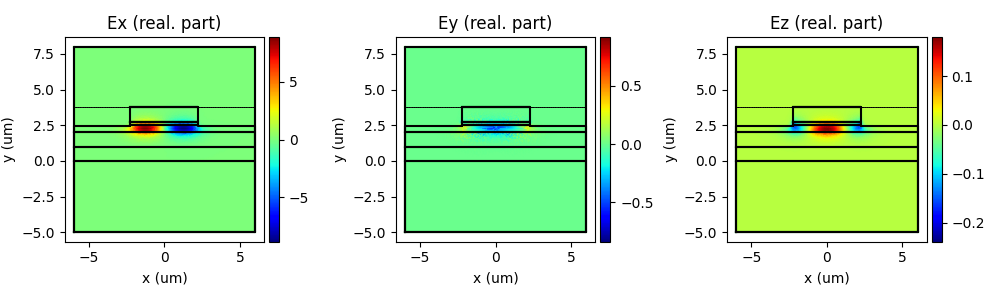

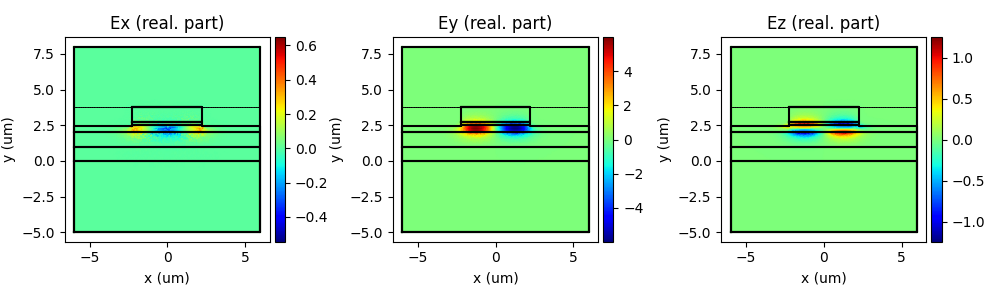

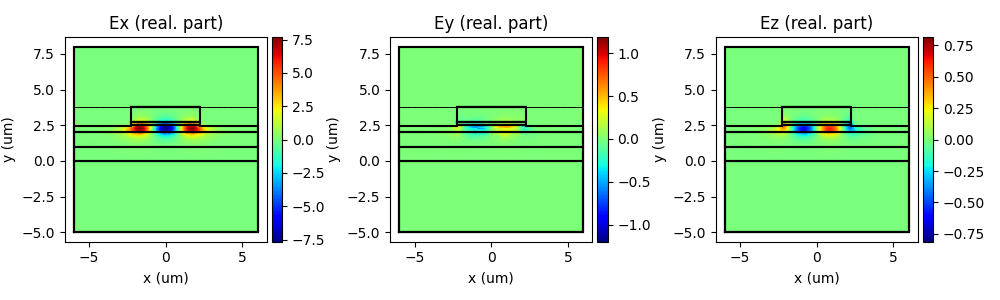

In [6]:
modes = mode.compute_modes(
    wavelength=1.55,
    num_modes=5,
    order=1,
    metallic_boundaries=["top", "bottom", "left", "right"],
    n_guess=3.4,
    return_modes=True
)

for i in range(len(modes)):
    print(f'Effective index - mode {i}: {modes[i].n_eff.real:.4f}')
    print(f'loss - mode {i}: {modes[i].calculate_propagation_loss(1e4):.2f} dB/cm')
    print(f"power: ", modes[i].calculate_power())
    print(f"TE fraction: ", modes[i].te_fraction)
    print(f"TM fraction: ", modes[i].tm_fraction)
    print(f"transversality: {modes[i].transversality}")
    print('#------------------------------------------#')
	
for m in modes:
	mode.plot_mode(m)

In [7]:
mode.transfer_results_to_device(TE_TM_idx = [0,1])

In [8]:
wl_vals = [1570,1555,1540,1525]
kappa_TE_vals = []
kappa_TM_vals = []

manager = enlighten.get_manager()
pbar = manager.counter(total=len(wl_vals), desc='Calculating EO response', unit='wavelength')
pbar_voltage = manager.counter(total=len(modulator.device.charge['V']), desc='Calculating EO response', unit='voltage index')
for wl in wl_vals:
    EO=ElectroOpticalSimulator(
        device=modulator.device,
        simulation_window=shapely.box(
            -modulator.w_metal_sig/2-modulator.metal_sep/2-2,
            -1,
            +modulator.w_metal_sig/2+modulator.metal_sep/2+2,
            modulator.h_L1 + modulator.h_L2+modulator.h_L3+modulator.h_L4+modulator.h_L5+modulator.h_L6+1
        ),
        wavelength=wl
    )

    EO.make_mesh()
    # fig, ax = EO.plot_mesh()
    # EO.plot_polygons(ax=ax)

    print(EO.mesh.nelements)

    EO.get_epsilon_optical()

    kappa_all_TE = []
    kappa_all_TM = []
    voltage_idxs = np.arange(0, len(modulator.device.charge['V']), 1)

    pbar_voltage.count=0
    for i in range(len(modulator.device.charge['V'])):
        kappa = EO.calculate_EO_response(
            voltage_idx=i,
            rot_x=0,
            rot_y=np.pi/4,
            rot_z=0,
            base_epsilon_voltage_idx=0,
            optical_mode_a='TE',
            optical_mode_b='TE',
            wavelength = wl/1e3
        )
        kappa_all_TE.append(kappa['InGaAsPElectroOpticalModel']['results'])

        kappa = EO.calculate_EO_response(
            voltage_idx=i,
            rot_x=0,
            rot_y=np.pi/4,
            rot_z=0,
            base_epsilon_voltage_idx=0,
            optical_mode_a='TM',
            optical_mode_b='TM',
            wavelength = wl/1e3
        )
        kappa_all_TM.append(kappa['InGaAsPElectroOpticalModel']['results'])

        pbar_voltage.update()

    kappa_all_TE = np.array(kappa_all_TE)
    kappa_all_TM = np.array(kappa_all_TM)

    kappa_TE_vals.append(kappa_all_TE)
    kappa_TM_vals.append(kappa_all_TM)

    pbar.update()

13910


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in log
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: overflow encountered in exp
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.py:1271: RuntimeWarning: invalid value encountered in power
  magnitude = new_self._magnitude**exponent
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.

13910


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in log
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: overflow encountered in exp
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.py:1271: RuntimeWarning: invalid value encountered in power
  magnitude = new_self._magnitude**exponent
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.

13910


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in log
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: overflow encountered in exp
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.py:1271: RuntimeWarning: invalid value encountered in power
  magnitude = new_self._magnitude**exponent
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.

13910


c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in log
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: invalid value encountered in sqrt
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\numpy\numpy_func.py:322: RuntimeWarning: overflow encountered in exp
  result_magnitude = func(*stripped_args, **stripped_kwargs)
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.py:1271: RuntimeWarning: invalid value encountered in power
  magnitude = new_self._magnitude**exponent
c:\Users\20230622\AppData\Local\anaconda3\envs\imodulator_venv\lib\site-packages\pint\facets\plain\quantity.

In [9]:
np.save(
'kappa_vals.npy',
{
    'wl_vals': wl_vals,
	'V': charge.V,
    'kappa_TE_vals': kappa_TE_vals,
    'kappa_TM_vals': kappa_TM_vals
}
)

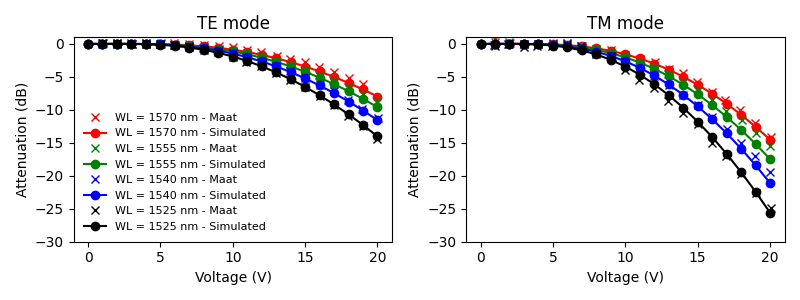

: 

In [ ]:
def f(x,A,B,C,D, E):
	return A+B*x + C*x**2 + D*x**3 + E*x**4

from scipy.optimize import curve_fit

data_maat = np.genfromtxt(
    r'.\maat_data_all_new.csv',
    delimiter=',',
    skip_header=0,
    dtype=float,
    filling_values=np.nan,
)

fig = plt.figure(figsize=(8,3))
gs = fig.add_gridspec(1,2)

ax_TE = fig.add_subplot(gs[0,0])
ax_TM = fig.add_subplot(gs[0,1])

colors = ['r', 'g', 'b', 'k']

idxs = [0,1,2,3]
for i,idx in enumerate(idxs):
    ax_TE.plot(
        data_maat[:,2*idx],
        data_maat[:,2*idx+1],
        color=colors[i],
        label=f'WL = {wl_vals[i]} nm - Maat',
        marker='x',
        linestyle='None'
    )

    V = modulator.device.charge['V']
    alpha_TE = -4.343*np.sum(kappa_TE_vals[i], axis=1).imag*1e-3

    ax_TE.plot(
            V,
            alpha_TE,
            color=colors[i],
            marker='o',
            label=f'WL = {wl_vals[i]} nm - Simulated'
    )

idxs = [0,1,2,3]
for i,idx in enumerate(idxs):
    ax_TM.plot(
        data_maat[:,2*4+2*idx],
        data_maat[:,2*4+2*idx+1],
        color=colors[i],
        label=f'WL = {wl_vals[i]} nm',
        marker='x',
        linestyle='None'
    )

    V = modulator.device.charge['V']
    alpha_TM = -4.343*np.sum(kappa_TM_vals[i], axis=1).imag*1e-3

    ax_TM.plot(
         V,
            alpha_TM,
            color=colors[i],
            marker='o',
            label=f'WL = {wl_vals[i]} nm - Simulated'
    )

ax_TE.set_ylim(-30,1)
ax_TM.set_ylim(-30,1)
ax_TE.set_xlabel('Voltage (V)')
ax_TM.set_xlabel('Voltage (V)')
ax_TE.set_ylabel('Attenuation (dB)')
ax_TM.set_ylabel('Attenuation (dB)')
ax_TE.set_title('TE mode')
ax_TM.set_title('TM mode')
ax_TE.legend(frameon=False, loc='lower left', fontsize=8)
# ax_TM.legend(frameon=False, loc='lower left', fontsize=8)

fig.tight_layout()
fig.savefig('EO_simulation.png', dpi=300)